In [1]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
 
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
 
# ── Time-Series ───────────────────────────────────────────────────────────
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.multicomp import pairwise_tukeyhsd
 
# ── ML ────────────────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import (Ridge, Lasso, ElasticNet,
                                   BayesianRidge, QuantileRegressor)
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, StackingRegressor)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

In [2]:
REGION_COLORS = {
    "New England":     "#1E40AF",
    "Mideast":         "#7C3AED",
    "Great Lakes":     "#059669",
    "Plains":          "#D97706",
    "Southeast":       "#DC2626",
    "Southwest":       "#DB2777",
    "Rocky Mountain":  "#0891B2",
    "Far West":        "#65A30D",
}
ACCENT, HIGHLIGHT, GREEN, AMBER, PURPLE, NEUTRAL = "#2563EB","#DC2626","#16A34A","#D97706","#7C3AED","#64748B"
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi":150, "savefig.bbox":"tight",
                     "savefig.facecolor":"white"})

In [3]:
raw = pd.read_csv("GDPDollarsRegions.csv", header=None)
raw.columns = ["GeoFIPS","Region","LineCode","Description"] + \
              [f"{yr}:Q{q}" for yr in range(2022,2026) for q in range(1,5)]
raw["Description"] = raw["Description"].str.strip()
Q_COLS = [c for c in raw.columns if ":" in c]


In [4]:
long = raw.melt(id_vars=["GeoFIPS","Region","LineCode","Description"],
                value_vars=Q_COLS, var_name="Quarter", value_name="GDP_M")
long["Period"]  = long["Quarter"].apply(
    lambda s: pd.Period(f"{s.split(':')[0]}Q{s.split(':')[1][1]}"))
long["Year"]    = long["Period"].apply(lambda p: p.year)
long["Qtr"]     = long["Period"].apply(lambda p: p.quarter)
long["GDP_B"]   = long["GDP_M"] / 1_000
long["GDP_T"]   = long["GDP_M"] / 1_000_000
long = long.sort_values(["Region","Description","Period"])

In [5]:
us_total_by_q = (long[long["Description"]=="All industry total"]
                 .groupby("Quarter")["GDP_M"].sum().reset_index())
us_total_by_q["Period"] = us_total_by_q["Quarter"].apply(
    lambda s: pd.Period(f"{s.split(':')[0]}Q{s.split(':')[1][1]}"))
us_total_by_q = us_total_by_q.sort_values("Period")
us_gdp = us_total_by_q["GDP_M"].values.astype(float)

In [6]:
# Region-level All-industry totals
reg_total = long[long["Description"]=="All industry total"].copy()
reg_total["QoQ_Growth"] = (
    reg_total.sort_values("Period")
             .groupby("Region")["GDP_M"].pct_change() * 100)
reg_total["YoY_Growth"] = (
    reg_total.sort_values("Period")
             .groupby("Region")["GDP_M"].pct_change(4) * 100)

In [7]:
# Industry breakdown (non-aggregate)
EXCL = {"All industry total","Private industries",
        "Government and government enterprises",
        "Durable goods manufacturing","Nondurable goods manufacturing",
        "Federal civilian","Military","State and local"}
ind_detail = long[~long["Description"].isin(EXCL)].copy()

In [8]:
latest_q  = Q_COLS[-1]
REGIONS   = raw["Region"].unique().tolist()
N_REGIONS = len(REGIONS)
 
print(f"Regions ({N_REGIONS}): {REGIONS}")
print(f"Quarters: {Q_COLS}")
print(f"Long-format rows: {len(long):,}")
print(f"US GDP range: ${us_gdp.min()/1e6:.2f}T – ${us_gdp.max()/1e6:.2f}T")

Regions (8): ['New England', 'Mideast', 'Great Lakes', 'Plains', 'Southeast', 'Southwest', 'Rocky Mountain', 'Far West']
Quarters: ['2022:Q1', '2022:Q2', '2022:Q3', '2022:Q4', '2023:Q1', '2023:Q2', '2023:Q3', '2023:Q4', '2024:Q1', '2024:Q2', '2024:Q3', '2024:Q4', '2025:Q1', '2025:Q2', '2025:Q3', '2025:Q4']
Long-format rows: 3,456
US GDP range: $25.11T – $31.25T


In [9]:
#Regional Pivot for ML Models
reg_pivot = reg_total.pivot_table(index="Region", columns="Quarter", values="GDP_M")
reg_pivot = reg_pivot.reindex(columns=Q_COLS)
X_all  = reg_pivot[Q_COLS[:-1]].values
y_all  = reg_pivot[Q_COLS[-1]].values
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_all)
tscv   = TimeSeriesSplit(n_splits=3)

In [11]:
%matplotlib inline

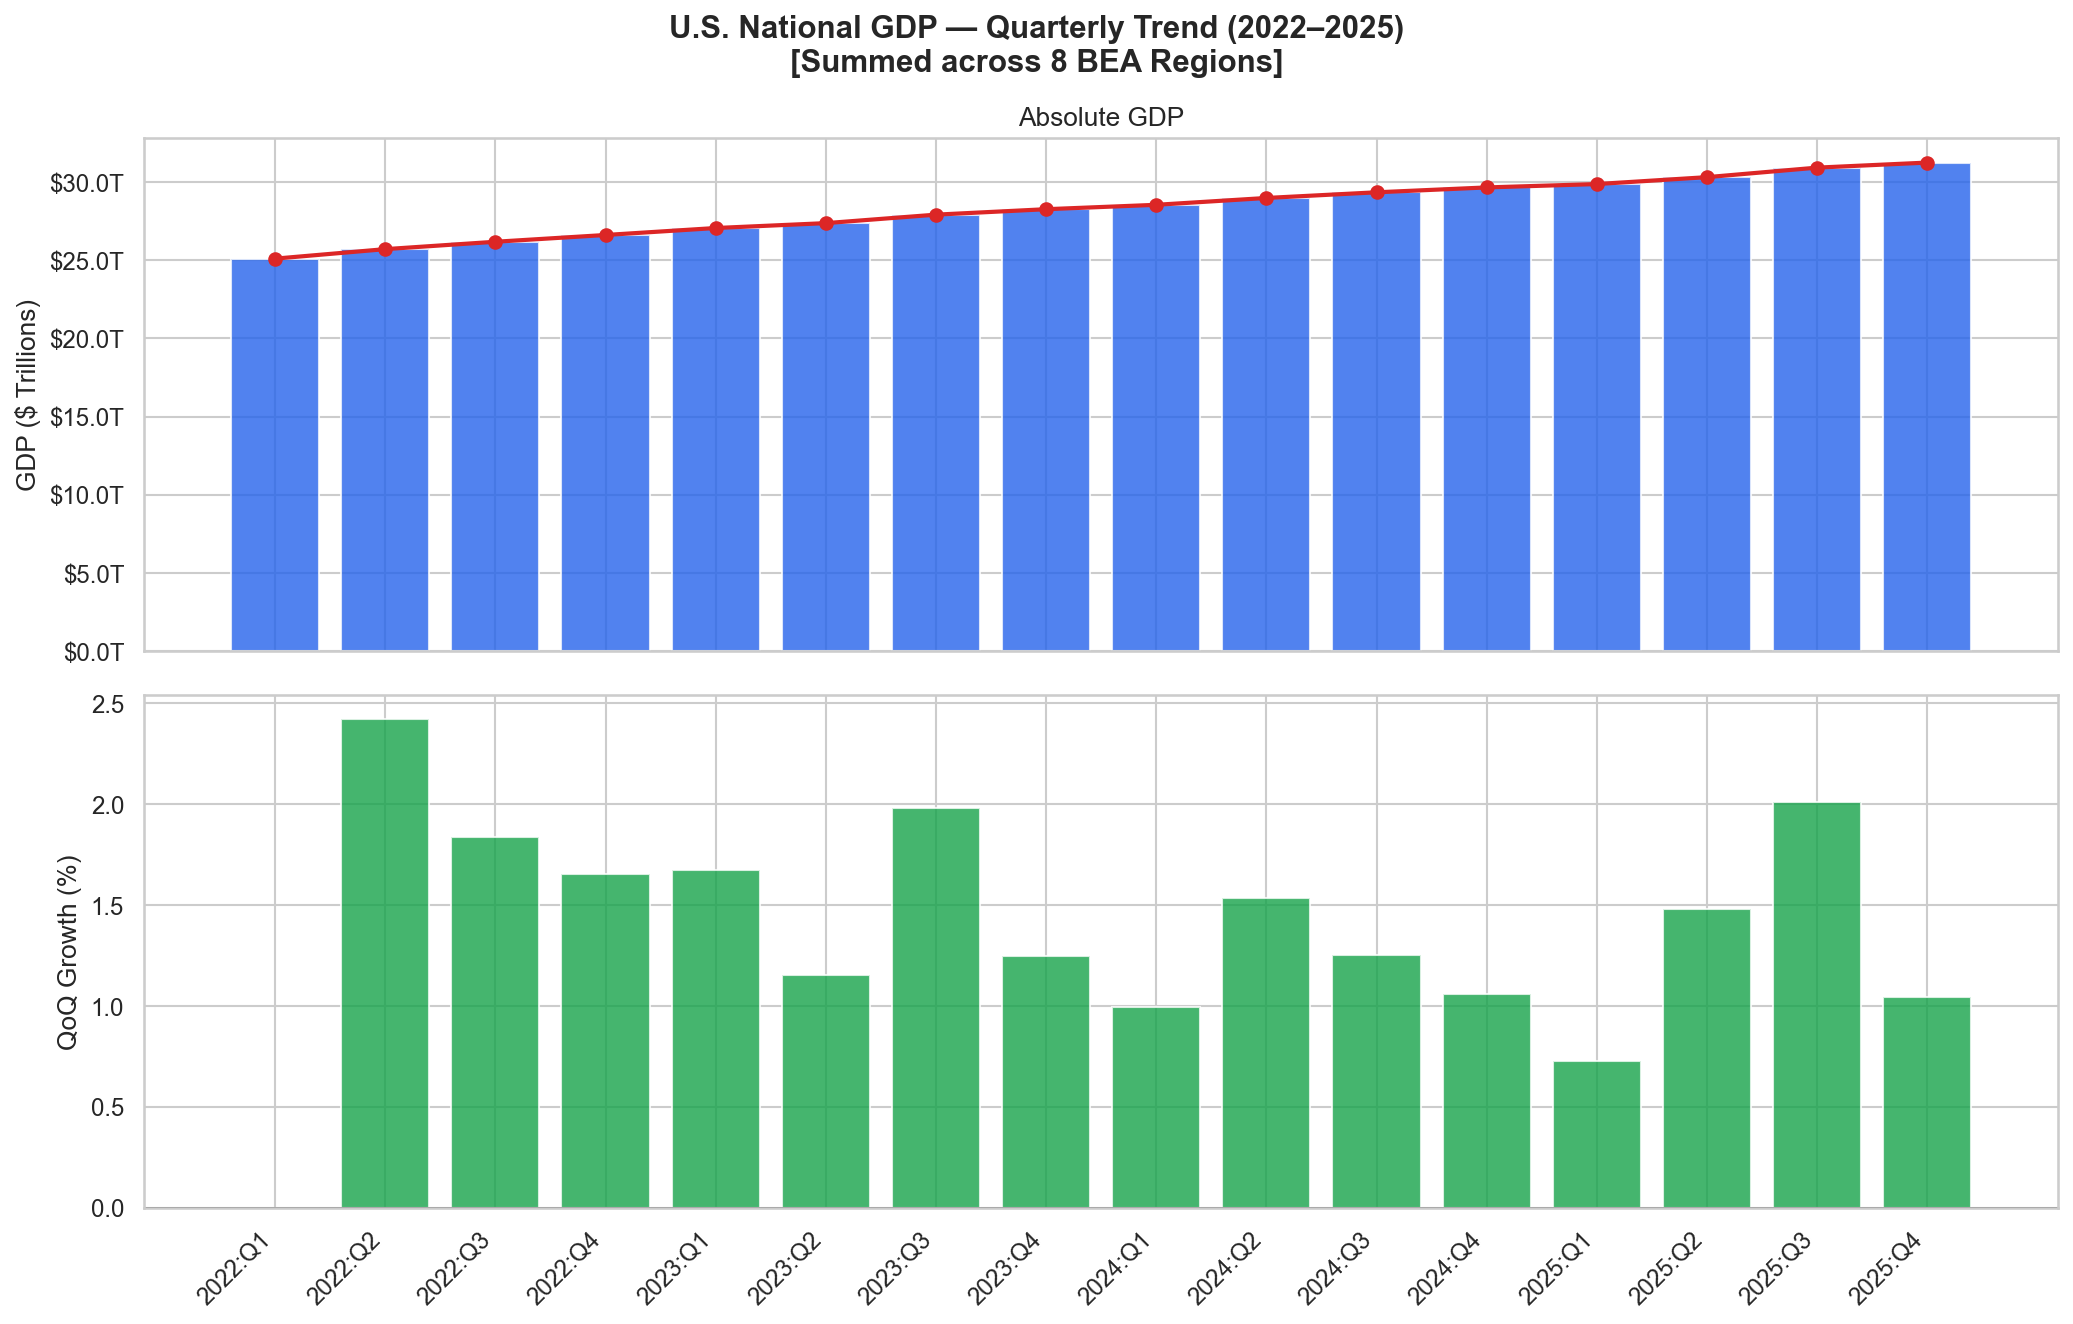

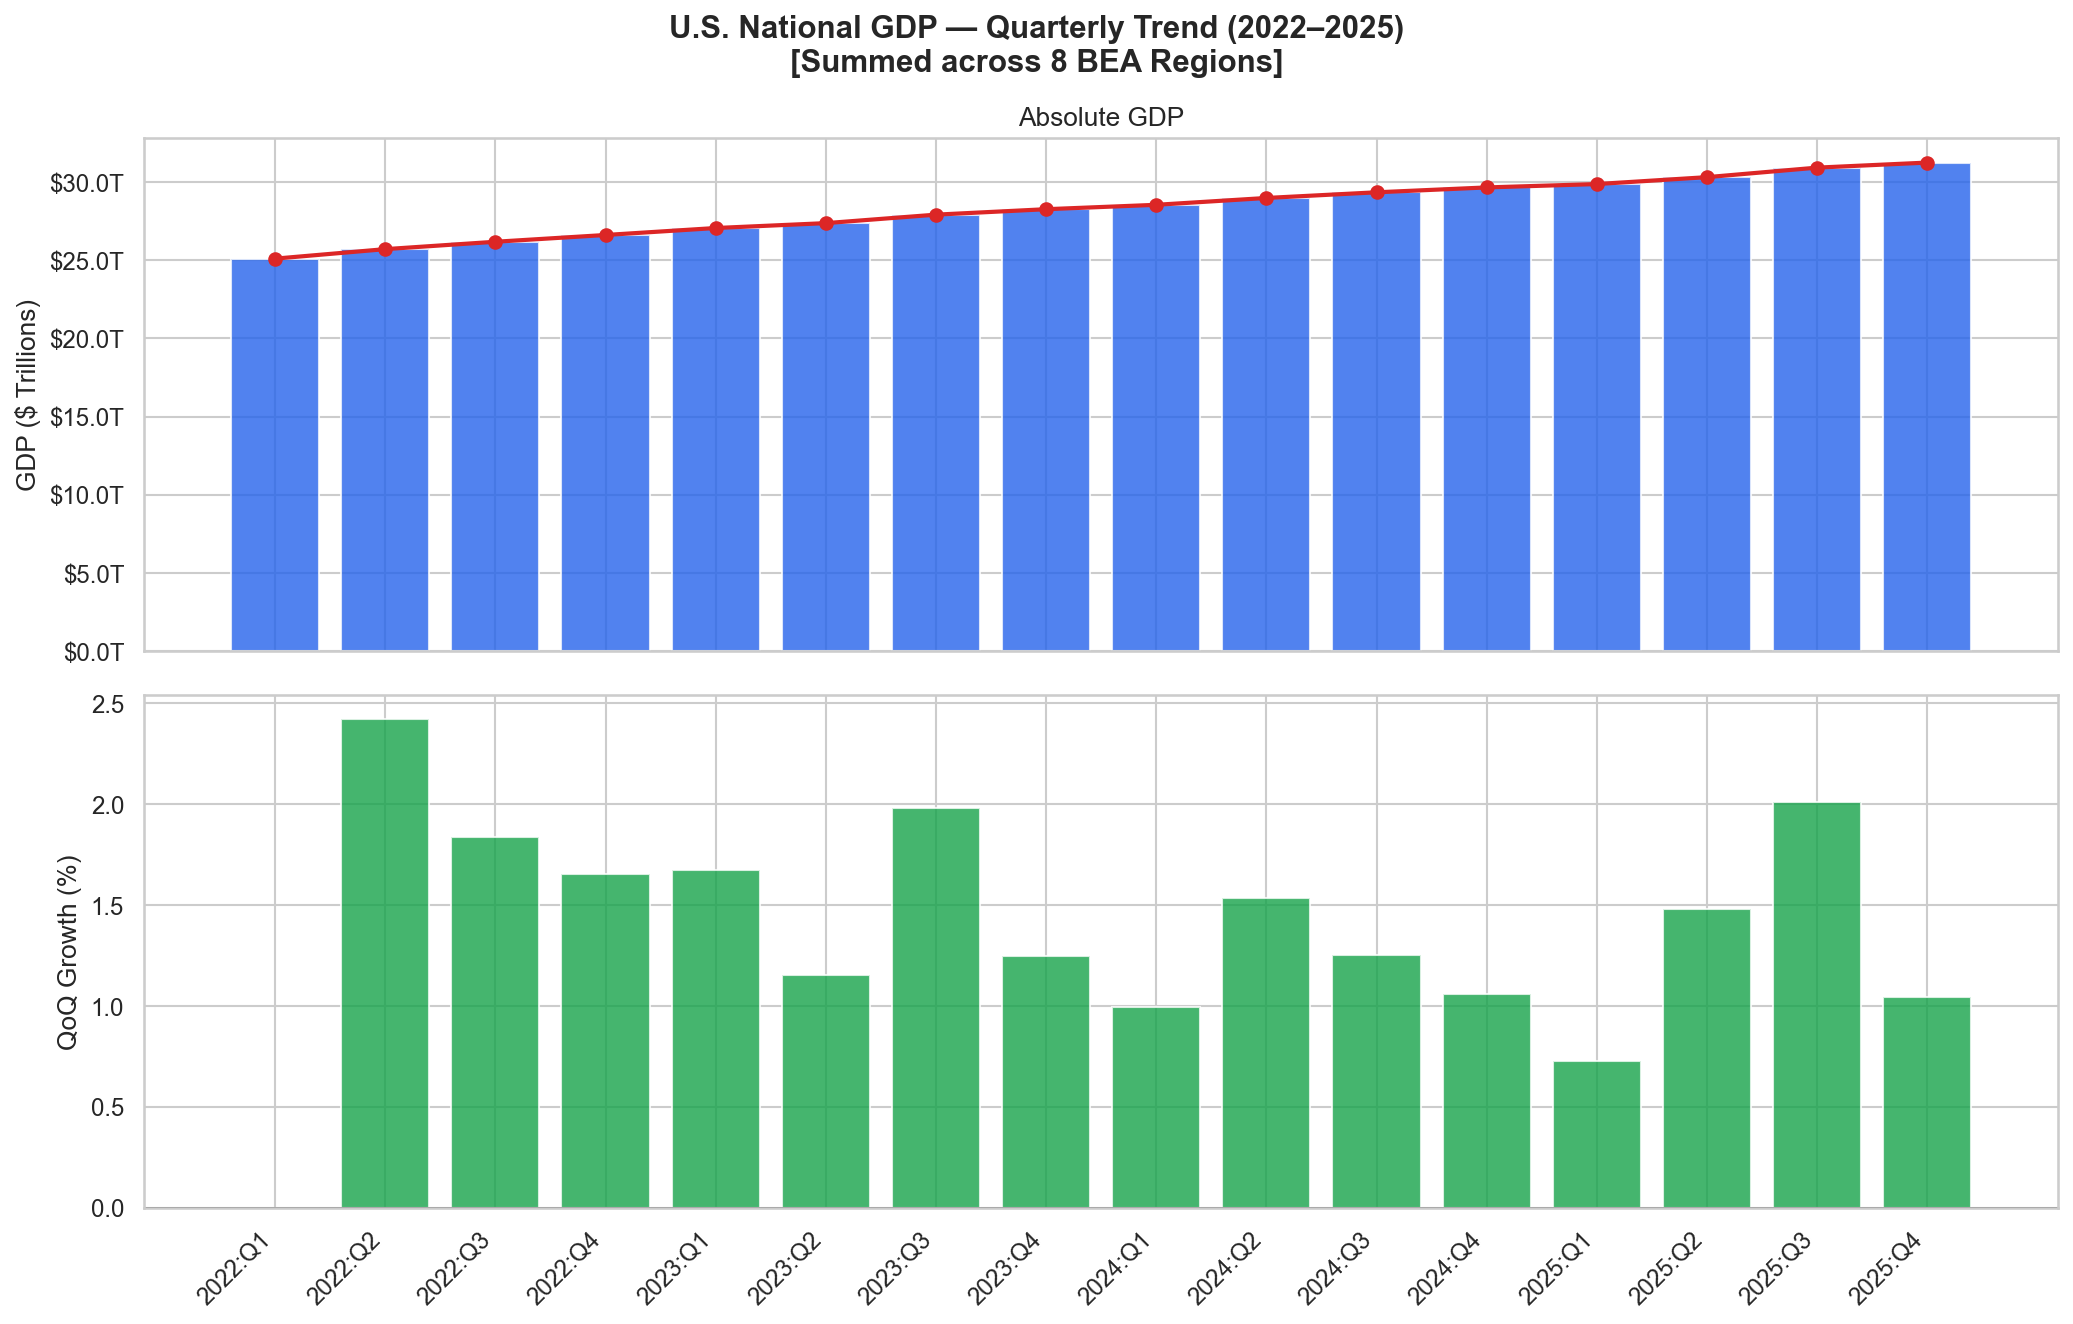

In [12]:
# ── 1-A  US Total GDP Trend ───────────────────────────────────────────────
fig, axes = plt.subplots(2,1,figsize=(14,9), sharex=True)
fig.suptitle("U.S. National GDP — Quarterly Trend (2022–2025)\n"
             "[Summed across 8 BEA Regions]", fontsize=15, fontweight="bold")
xs = list(range(len(Q_COLS)))
gdp_t = us_gdp / 1e6
axes[0].bar(xs, gdp_t, color=ACCENT, alpha=0.8)
axes[0].plot(xs, gdp_t, color=HIGHLIGHT, marker="o", lw=2)
axes[0].set_ylabel("GDP ($ Trillions)")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.1f}T"))
axes[0].set_title("Absolute GDP")
qoq = pd.Series(gdp_t).pct_change()*100
cols_bar = [GREEN if v>=0 else HIGHLIGHT for v in qoq.fillna(0)]
axes[1].bar(xs, qoq.fillna(0), color=cols_bar, alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("QoQ Growth (%)")
axes[1].set_xticks(xs); axes[1].set_xticklabels(Q_COLS, rotation=45, ha="right")
plt.tight_layout()
plt.show()

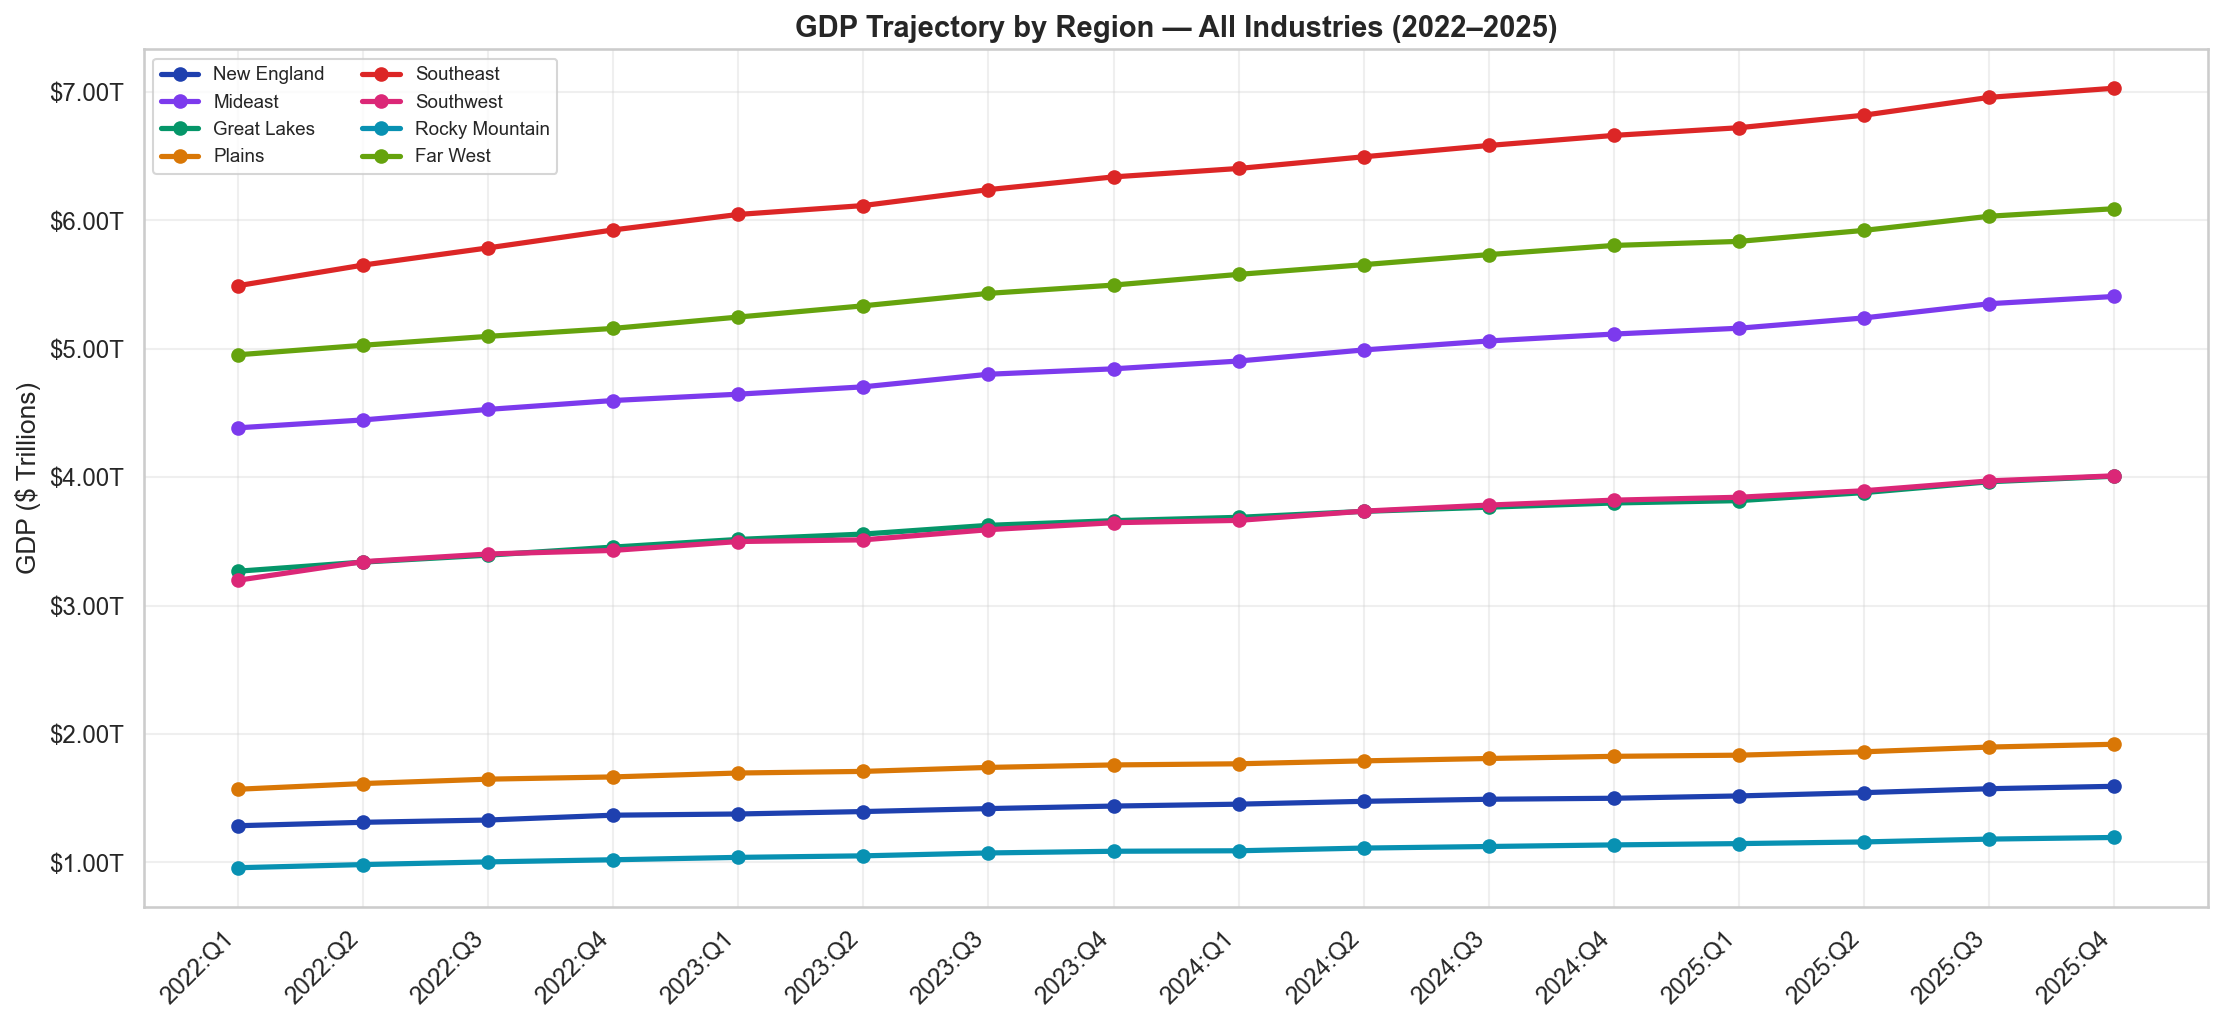

In [13]:
fig, ax = plt.subplots(figsize=(15,7))
for reg in REGIONS:
    rdf = reg_total[reg_total["Region"]==reg].sort_values("Period")
    ax.plot(range(len(Q_COLS)), rdf["GDP_T"].values, marker="o", lw=2.5,
            color=REGION_COLORS[reg], label=reg)
ax.set_xticks(range(len(Q_COLS)))
ax.set_xticklabels(Q_COLS, rotation=45, ha="right")
ax.set_ylabel("GDP ($ Trillions)"); ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_: f"${x:.2f}T"))
ax.set_title("GDP Trajectory by Region — All Industries (2022–2025)",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()